# MLB Batting Analysis

**Quick Note**: The terms "batter" and "hitter" may be used interchangeably in this notebook and project. They mean the same thing. 

# EDA and Preprocessing

In [2]:
%load_ext autoreload
%autoreload 2

In [21]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import src.data_loader as dl
import src.preprocessing as pp
import src.outlier_detection as od
import src.feature_selection as fs
import src.clustering as ct
import src.classification as cf
import src.visualization as vis

## Loading Data

In [22]:
data = dl.load_raw_data()

Loading raw data from '../data/raw/batting_2015_2024.csv'


## Quick Data Cleaning

Before we get started, we will fix columns we know are problematic.

The "Season" and "season" columns contain the same values. We will remove "season".

The "Age Rng" column that contains "Age" values in a weird format. We will remove "Age Rng".

There is a "Dol" column that contains dollar values with dollar signs, which makes pandas believe it is categorical. We will fix this.

In [23]:
data["Age Rng"] = data["Age Rng"].astype(str).str.extract(r"(\d+)").astype(int)
data = pp.remove_duplicate_columns(data, [("Season", "season"), ("Age", "Age Rng")])

data = pp.fix_dollar_column(data)


Check if 'Season' and 'season' columns are duplicates: True
'season' removed

Check if 'Age' and 'Age Rng' columns are duplicates: True
'Age Rng' removed

Fixed 'Dol' format


## Data Overview

In [24]:
print(f"Dimensions: {data.shape[0]} samples, {data.shape[1]} features")

categorical_features = data.select_dtypes(include=["object"]).columns
numerical_features = [feat for feat in data.columns if feat not in categorical_features]

print("\nFeature types:")
print(f"\nCategorical features: {len(categorical_features)}")
for feat in categorical_features:
    print(f"\t{feat}: {data[feat].nunique()} unique values")

print(f"\nNumerical features: {len(numerical_features)}")
print(f"\tSeasons: {data["Season"].unique().min()} - {data["Season"].unique().max()}")
print(f"\tAges: {data["Age"].unique().min()} - {data["Age"].unique().max()}")

print(f"\nSample of data:")
print(data.head())

Dimensions: 14051 samples, 319 features

Feature types:

Categorical features: 2
	Name: 3756 unique values
	Team: 31 unique values

Numerical features: 317
	Seasons: 2015 - 2024
	Ages: 19 - 45

Sample of data:
    IDfg  Season              Name Team  Age    G   AB   PA    H   1B  ...  \
0  11579    2015      Bryce Harper  WSN   22  153  521  654  172   91  ...   
1  10155    2015        Mike Trout  LAA   23  159  575  682  172   93  ...   
2   5038    2015    Josh Donaldson  TOR   29  158  620  711  184  100  ...   
3   4314    2015        Joey Votto  CIN   31  158  545  695  171  107  ...   
4   9218    2015  Paul Goldschmidt  ARI   27  159  567  695  182  109  ...   

   maxEV  HardHit  HardHit%  Events  CStr%   CSW%    xBA   xSLG  xwOBA  L-WAR  
0  116.0    188.0     0.477     394  0.118  0.226  0.292  0.544  0.418    9.3  
1  117.7    205.0     0.486     422  0.207  0.282  0.297  0.588  0.422    9.3  
2  113.6    232.0     0.465     499  0.145  0.255  0.279  0.545  0.390    8.7  
3

## Project Focus

Before we start plotting and preprocessing data, we want to consider the focus of this project: analyzing batting performance. 

The dataset we use also includes batting performance from pitchers. We want to remove these values to focus on batting performance from regular players, rather than pitchers.

More discussed in Plate Appearance Distribution section below.

## Plate Appearance (PA) Distribution

MLB defines a PA as a batter's turn at the plate ([link](https://www.mlb.com/glossary/standard-stats/plate-appearance)). In other words, it counts each player's turn to hit. This is different than an at-bat (AB), because a PA includes every completed trip to the plate, while an AB only counts outcomes that don't include walks, hit-by-pitches (HBP), etc.

Some players, such as pitchers, don't get many opportunities to hit (only get a few PA's), or have much less PA's than regular players.

MLB recently implemented a rule that exempts all pitchers from also needing to hit. 

This means predicting a pitcher's hitting ability is not particularly useful, given that they were never meant to be good hitters, and are no longer hitting in games. 

Regular players with limited PA's are also not as useful, as their stats are more prone to be influenced by luck. More discussed in the PA Threshold section below.

We will see how many players fall above specific PA thresholds and filter them based on the result.

In [25]:
print("Plate Appearance distribution")
print(data["PA"].describe())

pa_thresholds = [100, 250, 300, 500]
print(
    "\nPA's by threshold. These represent how many players had more PA's than these thresholds."
)
for threshold in pa_thresholds:
    split = data[data["PA"] >= threshold]
    print(f"PA >= {threshold}: {len(split)} samples")

Plate Appearance distribution
count    14051.000000
mean       122.559391
std        194.537007
min          0.000000
25%          0.000000
50%          6.000000
75%        182.000000
max        753.000000
Name: PA, dtype: float64

PA's by threshold. These represent how many players had more PA's than these thresholds.
PA >= 100: 4375 samples
PA >= 250: 2865 samples
PA >= 300: 2492 samples
PA >= 500: 1248 samples


## Setting a PA Threshold

According to the MLB Rate Stats Qualifiers ([link](https://www.mlb.com/glossary/standard-stats/rate-stats-qualifiers)), a batter must record at least 3.1 PA's per scheduled league game to qualify for certain invididual stat category leadership. 

Over a full season (162 games), this adds up to 502 PA's. 

Setting the PA threshold high, such as 500, shrinks our dataset to just 1248 samples. 

Setting it too low, such as 100, provides many more samples. But less PA's means stats could be more influenced by luck or randomness.

#### Comparing $\sigma$'s of different sample sizes

$\sigma_{300} / \sigma_{100} = \sqrt{100/300}= 0.577$

$\sigma^{2}_{300} / \sigma^{2}_{100} = 0.333$

$\sigma_{500} / \sigma_{300} = \sqrt{300/500}= 0.775$

$\sigma^{2}_{500} / \sigma^{2}_{300} = 0.600$

Going from 100 -> 300 PA's reduces $\sigma$ by roughly $42\%$

Going from 300 -> 500 PA's reduces $\sigma$ by roughly $22\%$

A threshold of 250 gives us a decent dataset size while reducing the influence of luck on player stats. 

## Filtering by PA Threshold

In [26]:
PA_THRESHOLD = 250
data = pp.filter_by_threshold(data, "PA", PA_THRESHOLD)


Remaining samples after filtering by 'PA': 2865


## Plotting Distributions

Now that we've set our focus on regular batters with enough PA's, we will take a look at the distributions of some key stats.

For definitions of key stats used below, please refer to the [FanGraphs Library](https://library.fangraphs.com/offense/offensive-statistics-list/).

Key stats used for visualization:
AVG, OBP, SLG, OPS, RBI, HR, BB%, K%, EV, Spd, wOBA, wRC+

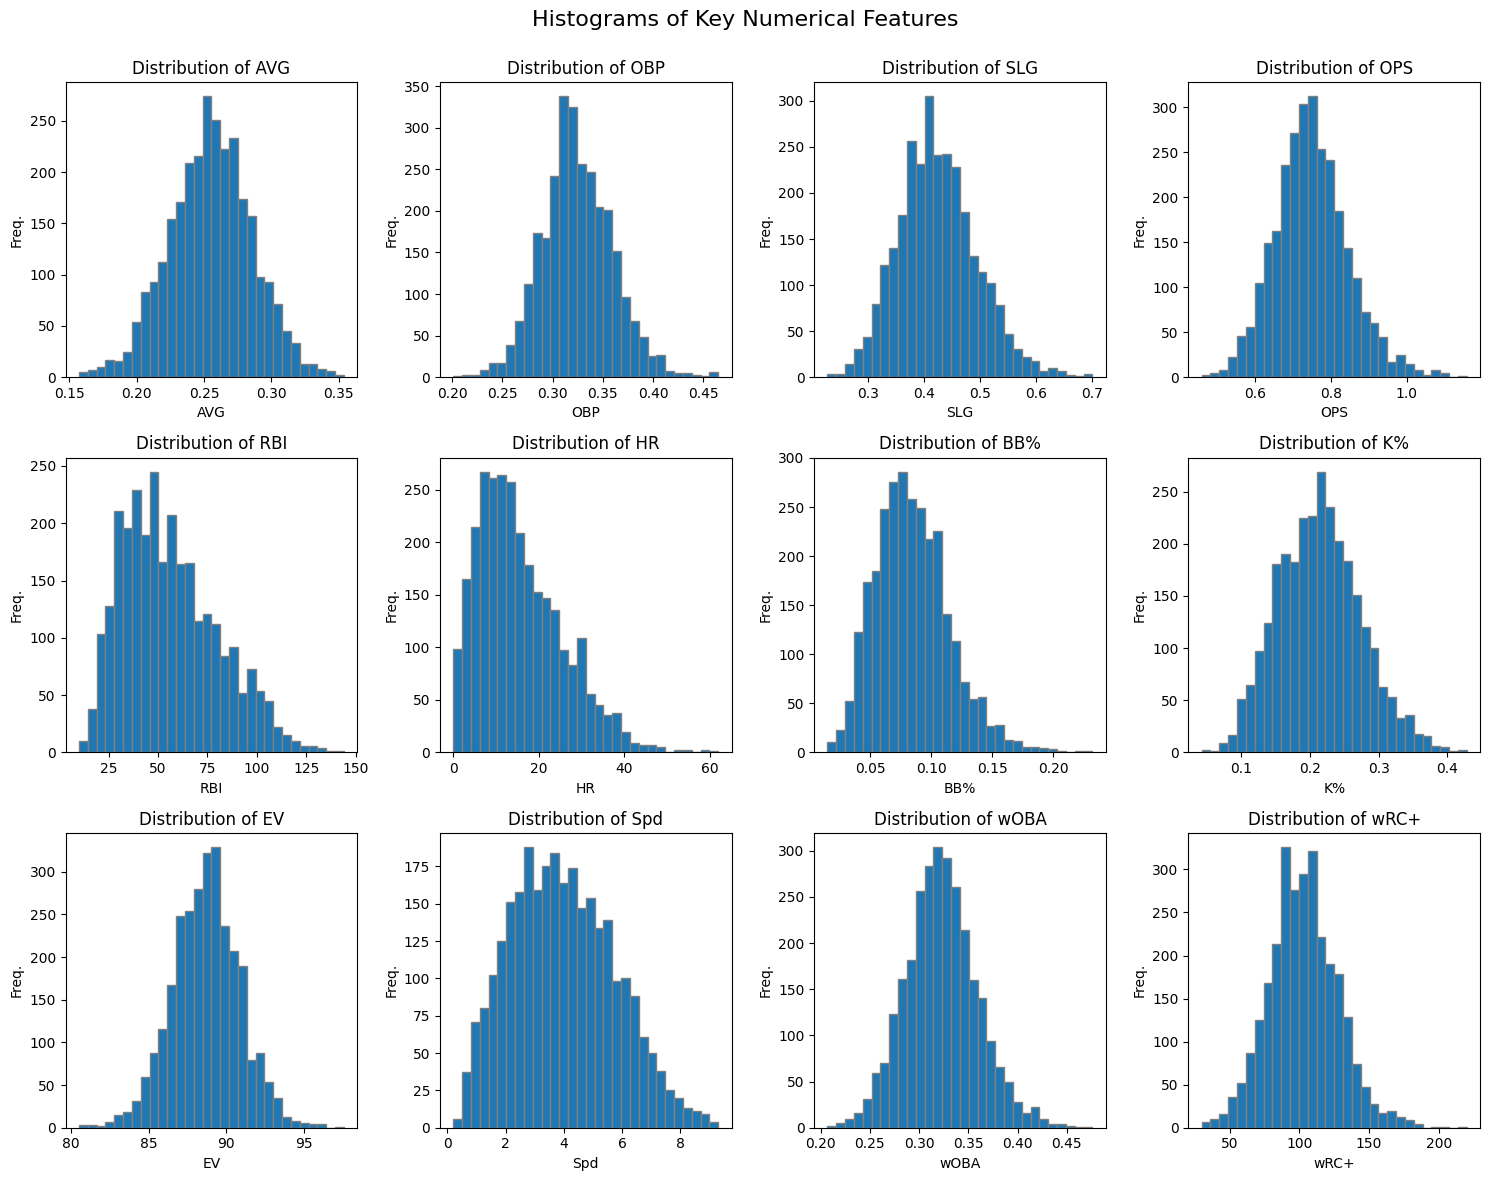

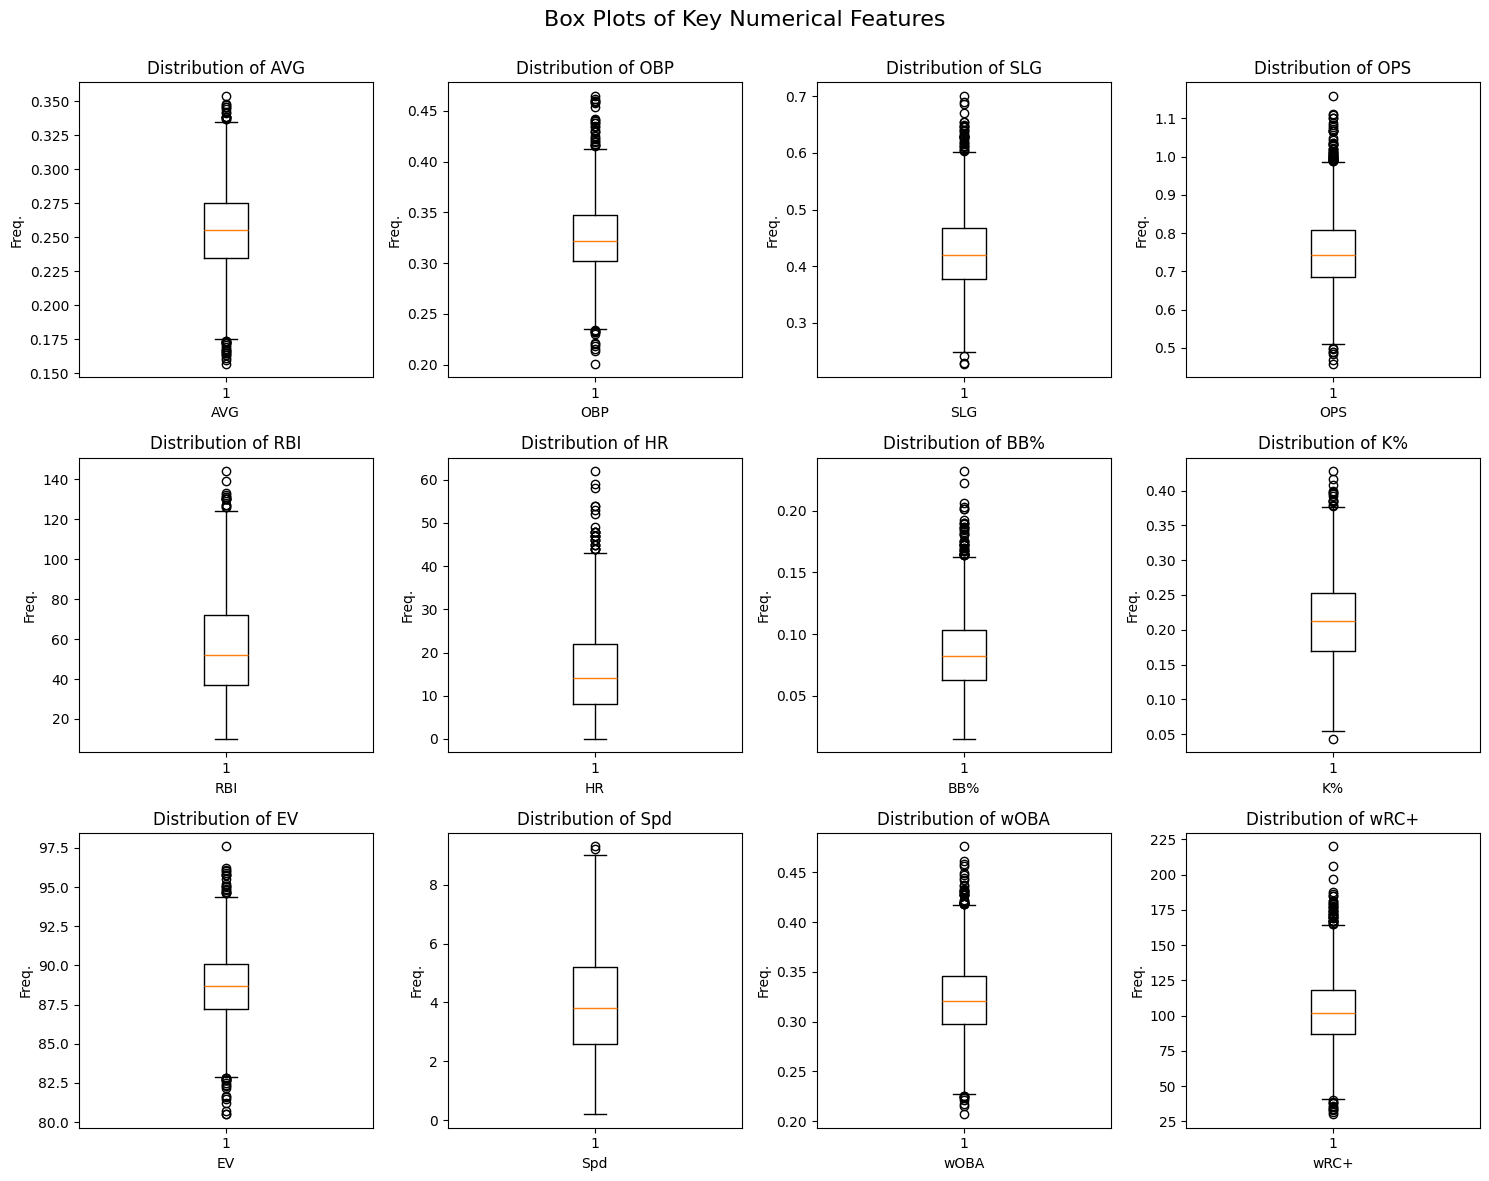

In [27]:
# fmt: off
KEY_STATS = ["AVG", "OBP", "SLG", "OPS", "RBI", "HR", "BB%", "K%", "EV", "Spd", "wOBA", "wRC+"]
# fmt: on

vis.plot_distributions(data, KEY_STATS, type="histograms")
vis.plot_distributions(data, KEY_STATS, type="box plots")

## Visualizing Relationships

We will create a heat map to see how much the key stats are correlated.

Features with high correlation (>= +-0.8):
OPS, wOBA: 0.9909
wOBA, wRC+: 0.9748
SLG, OPS: 0.9613
OPS, wRC+: 0.9561
SLG, wOBA: 0.9251
SLG, wRC+: 0.8906
OBP, wOBA: 0.8835
RBI, HR: 0.8706
OBP, wRC+: 0.8563
OBP, OPS: 0.8367


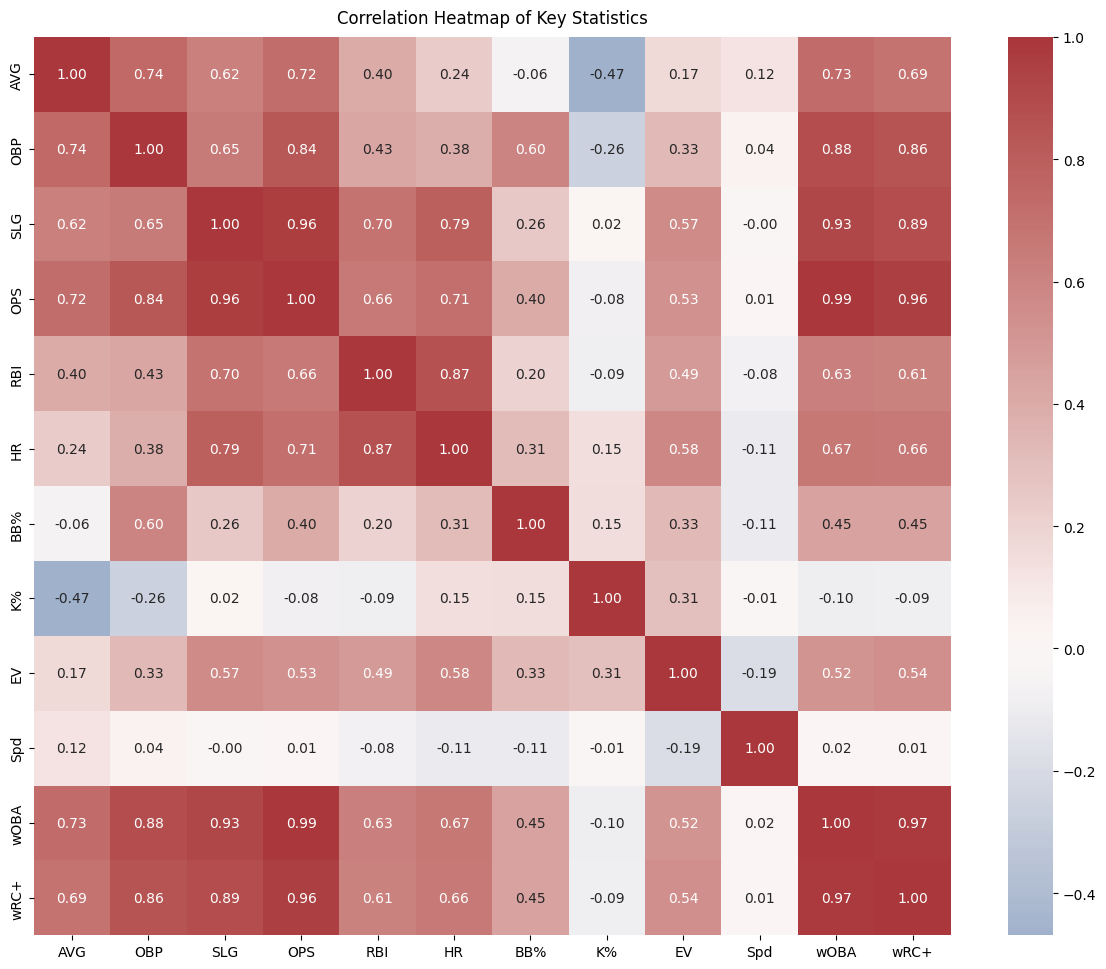

In [28]:
vis.plot_heatmap(data, KEY_STATS)

## Creating Performance Tiers

One of our potential research questions was whether we could classify hitters into performance tiers.

To do this, we need a target variable to place hitters into these tiers. 

We would like to do this before performing any preprocessing, such as standardization, as it is easier to interpret raw values.

We will use wRC+ as the target variable and create performance tiers based on it.

**While we could simply predict wRC+ using regression, classification into tiers provides more interpretable categories. A layman could easily understand that a player is "Elite", but may not easily understand what it means for a player to have a wRC+ of 150.**

### Why wRC+?

wRC+ has become an industry standard for measuring a player's offensive output. It is commonly used by teams and analysts to understand how good a hitter is.

Definition ([link](https://www.mlb.com/glossary/advanced-stats/weighted-runs-created-plus)): wRC+ takes the statistic Runs Created and adjusts that number to account for important external factors -- like ballpark or era. It's adjusted, so a wRC+ of 100 is league average and 150 would be 50 percent above league average.

It captures all aspects of offensive production in a single number:
- Hitting for good (batting) average
- Hitting for power (home runs)
- Getting on base (OBP)
- Context (ballpark factor, era)
  - What is ballpark factor? [link](https://www.mlb.com/glossary/advanced-stats/park-factor)
  - Era: for example, 30 home runs in 2024 is not recognized as equal to 30 home runs in 1920. This is to make offensive stats from different eras comparable, as rule changes, different pitching styles, etc., make offensive environments different. 
- etc.

Other stats, such as AVG, RBI, HR, etc., are what TV broadcasts often show. However, these stats don't provide enough context to be useful on their own.

What other metrics fail to pick up:
- AVG: Ignores players who walk a lot or hit for power
- RBI: Dependent on teammates getting on base
- HR: Ignores a player's ability to get on base
- OPS: Double-counts OBP, not adjusted for ballpark or era
- wOBA: Not scaled and not adjusted for ballpark or era
- etc.

### Performance Tier Thresholds
We decided to create 4 tiers, as too many thresholds may run into imbalance issues, while too little would not be able to capture different tiers effectively. 

Since the league average is set at 100 wRC+, we will set any samples in that neighbourhood to be average.


Performance Tier
Average          959
Below Average    844
Above Average    678
Elite            384
Name: count, dtype: int64


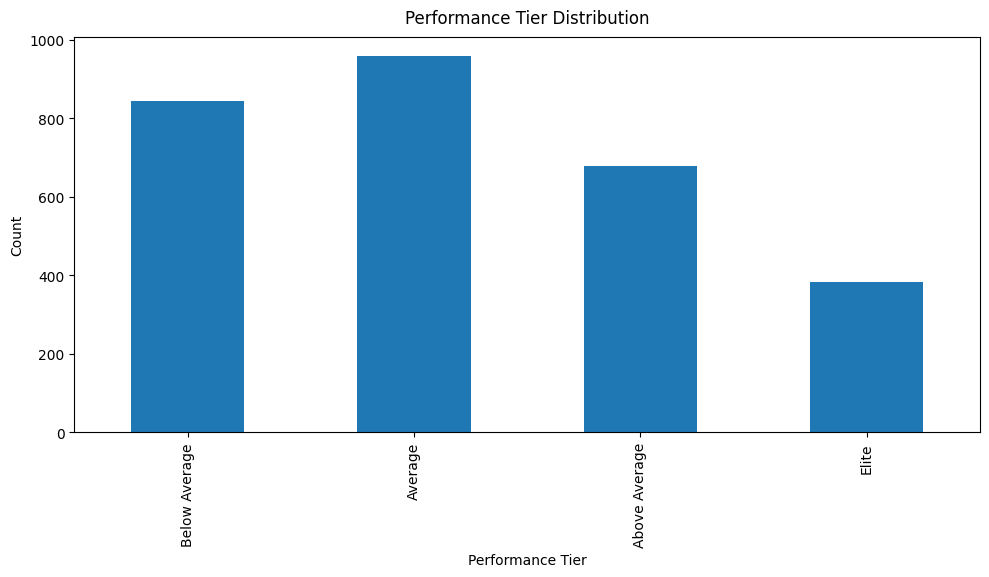

In [29]:
data = pp.add_performance_tiers(data)

tier_order = ["Below Average", "Average", "Above Average", "Elite"]
vis.plot_tier_distribution(data, tier_order)

## Missing Values

We handle missing values by removing or imputing.

### Saving Reference Data

Before we mess with any columns or values, we will save some data such as `Name` for reference when we do outlier detection. This will allow us to identify who the outliers are when we do outlier detection later on.

In [30]:
# saving some data for future reference, not for modelling
reference_data = data[["Name", "Season", "G", "PA", "wRC+", "Performance Tier"]]
reference_data.to_csv("../data/processed/batting_2015_2024_reference.csv", index=False)

### Removing Values

If a feature is missing over 50% of values, it is probably too incomplete to be useful. 

We also don't need player names and ID's, as they are not predictive and would make our model prone to overfitting.

In [31]:
data = pp.remove_features(data)

# remove ID
data = data.drop(columns=["Name", "IDfg"])

Total missing values before removing: 143010

Dropping columns with over 50% of values missing:
['KN%', 'KNv', 'PO%', 'wKN', 'wKN/C', 'FT% (sc)', 'FO% (sc)', 'EP% (sc)', 'SC% (sc)', 'KN% (sc)', 'UN% (sc)', 'vFT (sc)', 'vFO (sc)', 'vEP (sc)', 'vSC (sc)', 'vKN (sc)', 'FT-X (sc)', 'FO-X (sc)', 'EP-X (sc)', 'SC-X (sc)', 'KN-X (sc)', 'FT-Z (sc)', 'FO-Z (sc)', 'EP-Z (sc)', 'SC-Z (sc)', 'KN-Z (sc)', 'wFT (sc)', 'wFO (sc)', 'wEP (sc)', 'wSC (sc)', 'wKN (sc)', 'wFT/C (sc)', 'wFO/C (sc)', 'wEP/C (sc)', 'wSC/C (sc)', 'wKN/C (sc)', 'CS% (pi)', 'KN% (pi)', 'SB% (pi)', 'XX% (pi)', 'vCS (pi)', 'vKN (pi)', 'vSB (pi)', 'vXX (pi)', 'CS-X (pi)', 'KN-X (pi)', 'SB-X (pi)', 'XX-X (pi)', 'CS-Z (pi)', 'KN-Z (pi)', 'SB-Z (pi)', 'XX-Z (pi)', 'wCS (pi)', 'wKN (pi)', 'wSB (pi)', 'wXX (pi)', 'wCS/C (pi)', 'wKN/C (pi)', 'wSB/C (pi)', 'wXX/C (pi)', 'FRM']


### Imputing Values

Features missing less than 50% of values will be imputed. 

Also make sure each player is assigned a team.

In [32]:
data = pp.fix_team_values(data)
data = pp.impute_values(data)

Total missing values before imputing: 1009

Imputing columns with missing values using median.
['Fld', 'phLI', 'SF%', 'SFv', 'XX%', 'wSF', 'wSF/C', 'FS% (sc)', 'vFS (sc)', 'FS-X (sc)', 'FS-Z (sc)', 'wFS (sc)', 'wFS/C (sc)', 'UBR', 'wGDP', 'xBA', 'xSLG', 'xwOBA']
Total missing values after imputing: 0


## Encoding Categorical Features

We will apply one-hot encoding, since teams do not have an ordinal relationship, and our cardinality is not extremely high (30 unique teams + 1 for "Multiple").

In [33]:
data = pd.get_dummies(data, columns=["Team"], prefix="Team", drop_first=True)

## Convert SB/CS to Rate

A player can steal many bases, but if they also get caught stealing many times, then it doesn't provide much value.

A success rate better reflects a player's base-running ability and efficiency.

In [34]:
data = pp.convert_sb_cs_rate(data)

## Standardize Numerical Features

Baseball stats are prone to outliers.

For example, some players may hit 60 home runs while the league average is around 15.

This suggests that we should standardize rather than normalize.

In [35]:
data, scaler = pp.standardize_features(data)

## Data Augmentation

#### Class Imbalance
After creating performance tiers based on wRC+:
- Elite: 384 players
- Above Average: 678 players  
- Average: 959 players
- Below Average: 844 players

Elite players only make up a small portion of total players. This creates a class imbalance challenge, where the model may be more biased towards the majority classes, and improperly classify minority classes (Elite in our case). 

We can generate synthetic samples to deal with this problem (SMOTE). 

In [36]:
X = data.drop(columns=["Performance Tier"])
y = data["Performance Tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=42
)

X_resampled, y_resampled, sm = pp.apply_smote(X_train, y_train)


Class distribution of training set after SMOTE:
Performance Tier
Below Average    767
Average          767
Elite            767
Above Average    767
Name: count, dtype: int64


## Dimensionality Reduction

Our dataset has high dimensionality, so we try running PCA on it to reduce it to 2 dimensions.

We will also colour-code based on performance tiers. 

In the below scatter plot, we can see that each colour is decently bunched together in its own area, although there is noticeable overlap. 

This tells we have some class separability, where we can distinguish player tiers. This may be a good sign for our model. 

PC1 explains 17.39% of the data
PC2 explains 9.74% of the data
Combined, they explain: 27.13% of all data variation.


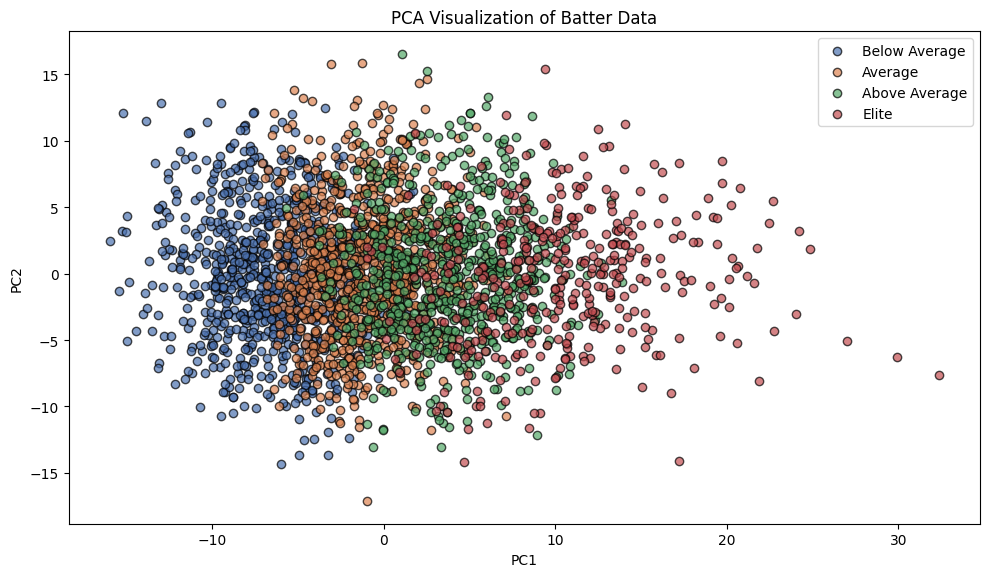

In [37]:
numerical_data = data.select_dtypes(include=[np.number])
pca_result, pca = pp.apply_pca(numerical_data)

tiers = data["Performance Tier"]

vis.plot_pca_by_tier(pca_result, tiers, tier_order)

## Saving Cleaned Data

In [38]:
data.to_csv("../data/processed/batting_2015_2024_cleaned.csv", index=False)
print(f"Cleaned data dimensions: {data.shape}")
binary_data = data.copy();

Cleaned data dimensions: (2865, 285)


## Key insights from EDA

### Visualization

Visually, from the histograms, we see that most key offensive stats approximate a normal distribution.

### Correlation

Many key stats are positively correlated, which may be expected. For example, OPS and wRC+ are highly correlated $(\text{Corr} = 0.96)$. OPS and wOBA are even more correlated $(\text{Corr} = 0.99)$. 

We may run into issues with multicollinearity, where highly correlated features contain redundant information.

Some stats have low correlation. For example, Spd and SLG have roughly 0 correlation. Spd and EV are slightly negatively correlated $(\text{Corr} = -0.19)$. This hints at distinct player archetypes mentioned in our proposal: power hitters vs speedsters vs others.

### Data Augmentation

There was some class imbalance, so we addressed this by generating synthetic samples (SMOTE). This was discussed in more detail above. 

### PCA

Our 2D PCA representation captures ~27% of the total information present in the original data, which means it doesn't capture the data super well.

This is not surprising as out dataset is highly dimensional, which makes it harder to compress to just 2 dimensions.

# Outlier Detection

## Isolation Forest

For the first outlier detection method, we will try an **Isolation Forest**. Our dataset is highly dimensional, and Isolation Forests work well with such data.

We will use a 5% contamination level to capture exceptional cases.

Number of outliers: 144

Top 10 outliers by wRC+:
                  Name  Season    G   PA   wRC+ Performance Tier
12597      Aaron Judge    2024  158  704  220.0            Elite
9645       Aaron Judge    2022  157  696  206.0            Elite
0         Bryce Harper    2015  153  654  197.0            Elite
4060        Mike Trout    2018  140  608  188.0            Elite
6850   Freddie Freeman    2020   60  262  186.0            Elite
4059      Mookie Betts    2018  136  614  185.0            Elite
9653    Yordan Alvarez    2022  135  561  185.0            Elite
11143    Shohei Ohtani    2023  135  599  181.0            Elite
12600        Juan Soto    2024  157  713  181.0            Elite
2705        Mike Trout    2017  114  507  180.0            Elite

Bottom 10 outliers by wRC+:
                  Name  Season    G   PA  wRC+ Performance Tier
2675         Yan Gomes    2016   74  264  30.0    Below Average
1256       Rene Rivera    2015  110  319  32.0    Below Average
11126   Cristi

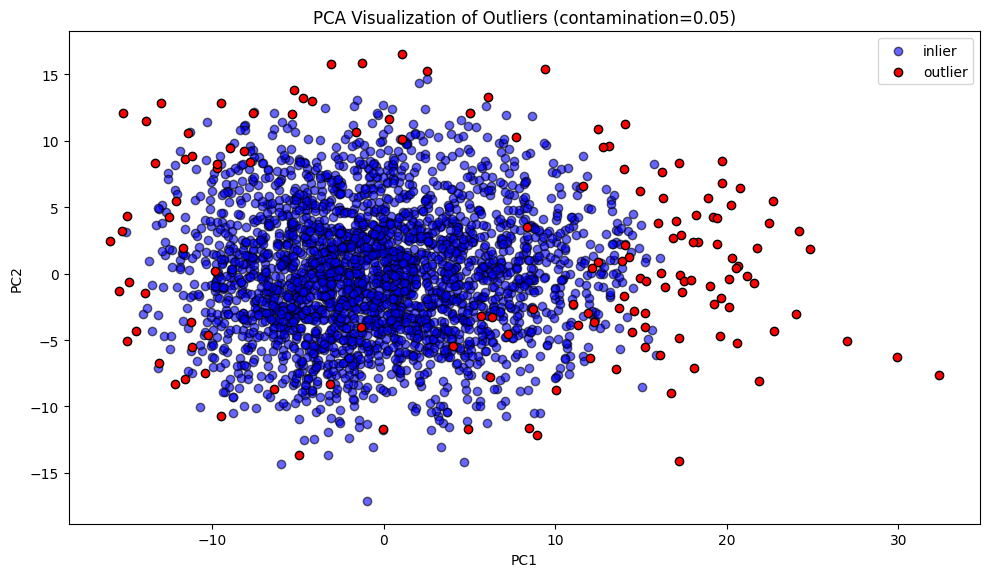

In [39]:
X = data.drop(columns=["Performance Tier"])

contamination = 0.05  # try 5% contamination and check results
iso_forest, y_pred_iso = od.detect_outliers_isolation_forest(X, contamination)
outliers_data_iso = reference_data[y_pred_iso == -1]

od.analyze_outliers(outliers_data_iso)
vis.plot_outliers(pca_result, y_pred_iso, contamination)

## Local Outlier Factor 

Our Second Outlier dectecion we will use is the **Local Outlier Factor**. LOF detects local anomalies by comparing each point to the density of its neighbors, making it effective at finding outliers hidden within clusters.

Same as before, we will use a 5% contamination level.

Number of outliers: 144

Top 10 outliers by wRC+:
                  Name  Season    G   PA   wRC+ Performance Tier
12597      Aaron Judge    2024  158  704  220.0            Elite
9645       Aaron Judge    2022  157  696  206.0            Elite
6850   Freddie Freeman    2020   60  262  186.0            Elite
12599    Shohei Ohtani    2024  159  731  179.0            Elite
12623      Kyle Tucker    2024   78  339  179.0            Elite
6855     Marcell Ozuna    2020   60  267  178.0            Elite
2701       Aaron Judge    2017  155  678  174.0            Elite
11162      Aaron Judge    2023  106  458  173.0            Elite
1           Mike Trout    2015  159  682  171.0            Elite
8171      Byron Buxton    2021   61  254  171.0            Elite

Bottom 10 outliers by wRC+:
                  Name  Season    G   PA  wRC+ Performance Tier
11126   Cristian Pache    2022   91  260  33.0    Below Average
1344     Danny Santana    2015   91  277  38.0    Below Average
3121        Ad

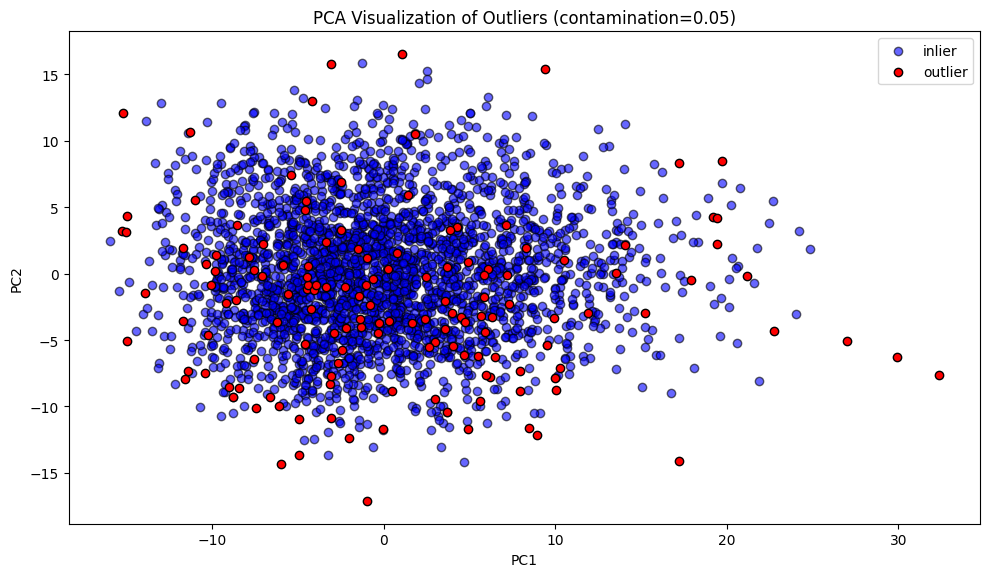

In [40]:
lof, y_pred_lof, lof_scores = od.detect_outliers_lof(
    X, contamination=contamination, n_neighbors=20
)
outliers_data_lof = reference_data[y_pred_lof == -1]

od.analyze_outliers(outliers_data_lof)
vis.plot_outliers(pca_result, y_pred_lof, contamination)

## Checking Overlap of Outliers

In [41]:
# Compare LOF and Isolation Forest results
lof_outliers = set(np.where(y_pred_lof == -1)[0])
iso_outliers = set(np.where(y_pred_iso == -1)[0])

print(f"Overlap: {len(lof_outliers & iso_outliers)}")
print(f"ISO-only: {len(iso_outliers - lof_outliers)}")
print(f"LOF-only: {len(lof_outliers - iso_outliers)}")

Overlap: 41
ISO-only: 103
LOF-only: 103


## Outlier Detection Summary

Taking a look at the players identified as outliers, anyone with some baseball knowledge should not be surprised at some of these names. 
- The top outliers by wRC+ are all MVP-caliber players who are among the best hitters ever. 
- The bottom outliers by wRC+ are all career below average hitters, not known for their hitting prowess. 

However, the PCA visualizations of the two methods tell a slightly different story.
- LOF includes labels a lot more _Average_ players as outliers compared to Isolation Forest.

Nothing stands out as suspicious or _out of the ordinary_.

These outliers represent legitimate extreme performances, rather than erroneous data.

**We will NOT remove outliers**

Removing these outliers would:
- Introduce bias by artificially removing real player performances.
- Impede on our model's ability to identify real occurrences of extreme performance.

# Feature Selection

## Removing Features using Domain Knowledge

Before applying feature selection algorithms, we will manually remove some features based on domain knowledge. 

Summary of removed features:

- Counting stats
  - Stats based on quantity, such as PA, AB, H, BB, SO, etc.
  - For most of these, we have rate based equivalents, such as AVG (H / AB), BB% (BB / PA), K% (SO / PA), etc. 
  - During preprocessing, we filtered our data set to players with over 250 PA's, but oftentimes the leaders for most PA's in a season hover above 700.
    - Players who have less PA's for reasons such as injury have an inherent disadvantage when it comes to counting based stats.
  - We don't want to simply teach our model that more PA == good and less PA == bad.
- Value stats
  - Stats based on player value, such as WAR, Offensive Runs Above Average, etc.
  - Similar to counting stats, value stats are reliant on time played.
  - They also create data leakage, because they feed into our target variable (wRC+).
    - We are basically giving the model the answer in small, separate pieces.
- Context dependent stats
  - Some stats are dependent on context, such as WPA, RE24, etc. 
- Pitch related stats
  - Stats tracking pitch values such as wFB, wSL, etc.
    - Creates data leakage, as mentioned above in value stats.
  - Pitch type percentages, velocity, and movement are out of the hitter's control.
    - A hitter does not control how often pitchers throw fastballs, how fast they are thrown, and how much they move.
- Non-Plus stats
  - Many stats have a _Plus_ version that is normalized such that 100 is the league average of a given year, and accounts for factors such as ballparks.
    - For example, Miguel Cabrera's .895 OPS in 2014 was 50 percent better than the MLB average after being adjusted for league and park factors. As a result, his OPS+ was 150.
  - The reason for Plus stats is because league averages for stats vary year-to-year.
    - For example, let's say AVG across all players in 2024 is less than AVG in 2015.
    - This does not necessarily reflect batter skill dropping, but rather pitcher skill improving, accompanied by the rise of the [Three True Outcomes](https://www.baseball-reference.com/bullpen/Three_True_Outcomes).
  - So, we will remove any stats that have a Plus version.
- Other
  - OPS = OBP + SLG. We have a perfect linear dependence.
  - wOBA: Corr = 0.99 for wOBA and OPS, check [here](https://library.fangraphs.com/offense/woba/) to see formula.
  - ISO = SLG - AVG
  - BABIP = (H - HR) / (AB - K - HR + SF)


In [42]:
# check plus stat correlation
data = data.drop(columns=["wRC+", "wRC"])  # the target variable
data = fs.remove_stats(data)

print(f"\nNumber of features remaining: {len(data.columns)}")
print(data.columns.tolist())

Removing non_plus_stats: ['Hard%', 'AVG', 'FB%', 'OBP', 'Soft%', 'Cent%', 'ISO', 'SLG', 'GB%', 'K%', 'Pull%', 'Oppo%', 'BABIP', 'Med%', 'BB%']
Removing pitch_specific_stats: ['FA% (sc)', 'FC% (sc)', 'FS% (sc)', 'SI% (sc)', 'SL% (sc)', 'CU% (sc)', 'KC% (sc)', 'CH% (sc)', 'vFA (sc)', 'vFC (sc)', 'vFS (sc)', 'vSI (sc)', 'vSL (sc)', 'vCU (sc)', 'vKC (sc)', 'vCH (sc)', 'FA-X (sc)', 'FC-X (sc)', 'FS-X (sc)', 'SI-X (sc)', 'SL-X (sc)', 'CU-X (sc)', 'KC-X (sc)', 'CH-X (sc)', 'FA-Z (sc)', 'FC-Z (sc)', 'FS-Z (sc)', 'SI-Z (sc)', 'SL-Z (sc)', 'CU-Z (sc)', 'KC-Z (sc)', 'CH-Z (sc)', 'wFA (sc)', 'wFC (sc)', 'wFS (sc)', 'wSI (sc)', 'wSL (sc)', 'wCU (sc)', 'wKC (sc)', 'wCH (sc)', 'wFA/C (sc)', 'wFC/C (sc)', 'wFS/C (sc)', 'wSI/C (sc)', 'wSL/C (sc)', 'wCU/C (sc)', 'wKC/C (sc)', 'wCH/C (sc)', 'O-Swing% (sc)', 'Z-Swing% (sc)', 'Swing% (sc)', 'O-Contact% (sc)', 'Z-Contact% (sc)', 'Contact% (sc)', 'Zone% (sc)', 'CH% (pi)', 'CU% (pi)', 'FA% (pi)', 'FC% (pi)', 'FS% (pi)', 'SI% (pi)', 'SL% (pi)', 'vCH (pi)', 'vC

## Recursive Feature Elimination with Cross Validaiton (RFECV)

In [43]:
X = data.drop(columns=["Performance Tier"])
y = data["Performance Tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=42
)

rfecv, features_rfecv = fs.apply_rfecv(X_train, y_train)

Number of selected features: 5
Selected features: ['AVG+' 'OBP+' 'SLG+' 'HR/FB%+' 'xSLG']


## LASSO Regression 

In [44]:
lrcv, features_lasso = fs.apply_lasso(
    X_train, y_train, Cs=np.logspace(-4, 2, 40), n_splits=5, tol=1e-4
)

X_train_lasso = X_train[features_lasso]
X_test_lasso = X_test[features_lasso]

c:\Users\ajaxm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1955: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Number of selected features: 59
Selected features: ['Season', 'Age', 'BB/K', 'GB/FB', 'IFFB%', 'HR/FB', 'IFH%', 'BUH%', 'Spd', 'O-Swing%', 'Z-Swing%', 'Z-Contact%', 'Contact%', 'Zone%', 'F-Strike%', 'TTO%', 'BB%+', 'K%+', 'OBP+', 'SLG+', 'LD+%', 'FB%+', 'HR/FB%+', 'Pull%+', 'Cent%+', 'Soft%+', 'Med%+', 'Hard%+', 'EV', 'LA', 'Barrel%', 'maxEV', 'HardHit%', 'xBA', 'xSLG', 'Team_ATL', 'Team_BOS', 'Team_CHC', 'Team_CIN', 'Team_CLE', 'Team_COL', 'Team_DET', 'Team_HOU', 'Team_KCR', 'Team_LAD', 'Team_MIA', 'Team_MIL', 'Team_Multiple', 'Team_NYM', 'Team_OAK', 'Team_PHI', 'Team_PIT', 'Team_SDP', 'Team_SEA', 'Team_SFG', 'Team_STL', 'Team_TBR', 'Team_TEX', 'SB%']


## Cluster Analysis

## K-Means Analysis (k= 2 to 10)

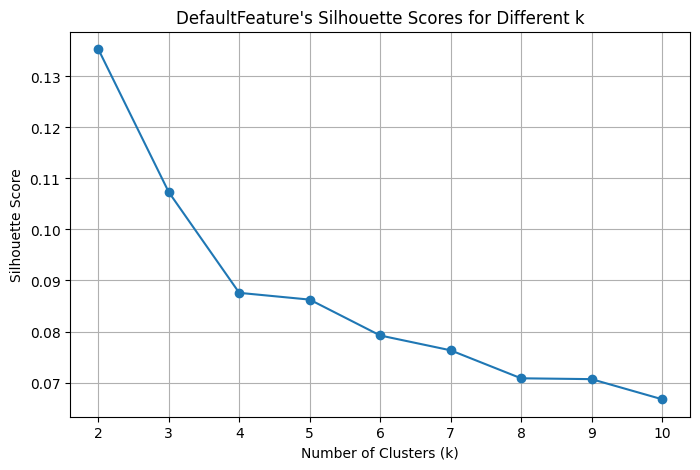

Best k for Default features: 2


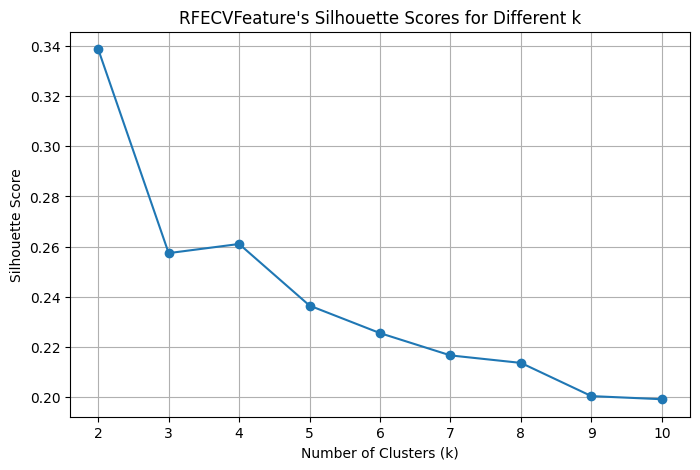

Best k for RFECV features: 2


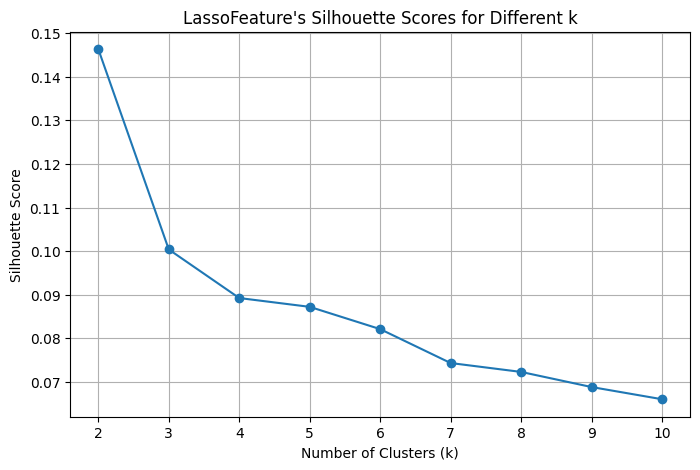

Best k for Lasso features: 2


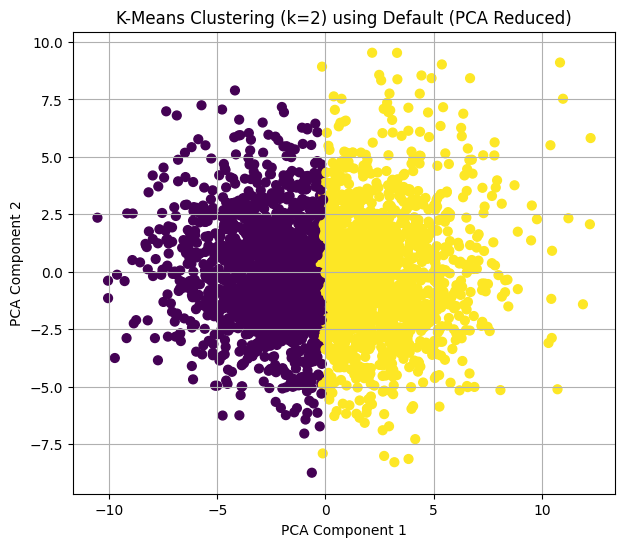

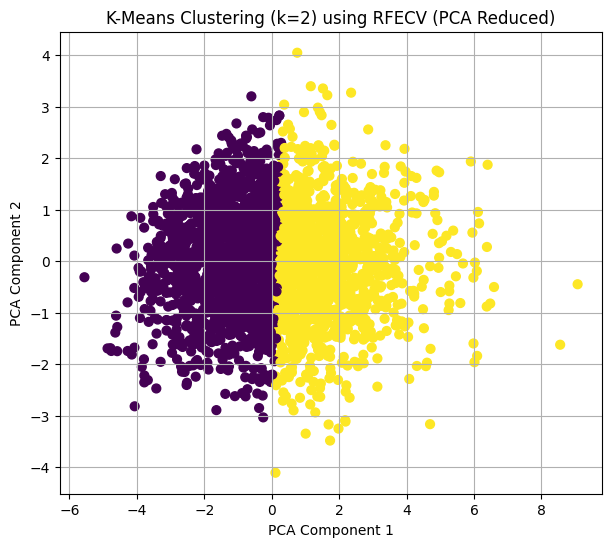

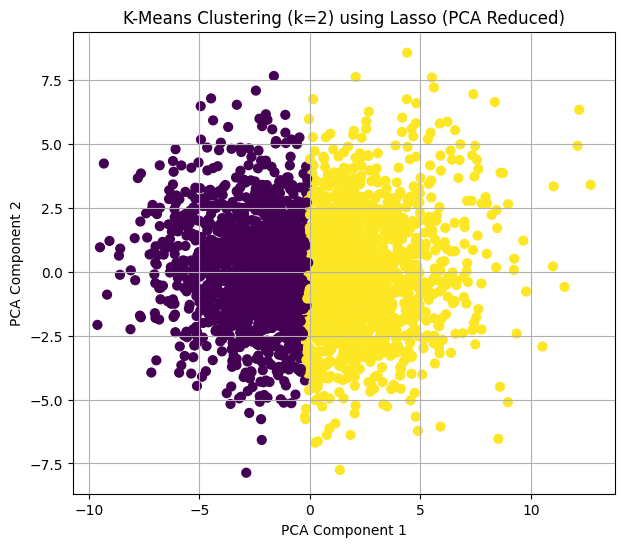

In [45]:
X_norm = X
X_rfecv = X[features_rfecv]
X_lasso = X[features_lasso]

best_k_norm = ct.perform_kmeans_clustering(X_norm,"Default", k_min=2, k_max=10, random_state=42)
print(f"Best k for Default features: {best_k_norm}")
best_k_rfecv = ct.perform_kmeans_clustering(X_rfecv,"RFECV", k_min=2, k_max=10, random_state=42)
print(f"Best k for RFECV features: {best_k_rfecv}")
best_k_lasso = ct.perform_kmeans_clustering(X_lasso,"Lasso", k_min=2, k_max=10, random_state=42)
print(f"Best k for Lasso features: {best_k_lasso}")

vis.plot_best_k(X_norm,"Default", best_k_norm, random_state=42)
vis.plot_best_k(X_rfecv,"RFECV", best_k_rfecv, random_state=42)
vis.plot_best_k(X_lasso,"Lasso", best_k_lasso, random_state=42)

## Method #2

## Classification

## Random Forest 


Random Forest Metrics:
Accuracy: 0.9389
Precision: 0.9390
Recall: 0.9389
F1 Score: 0.9386
CV_mean_accuracy: 0.9341
CV_std_accuracy: 0.0108


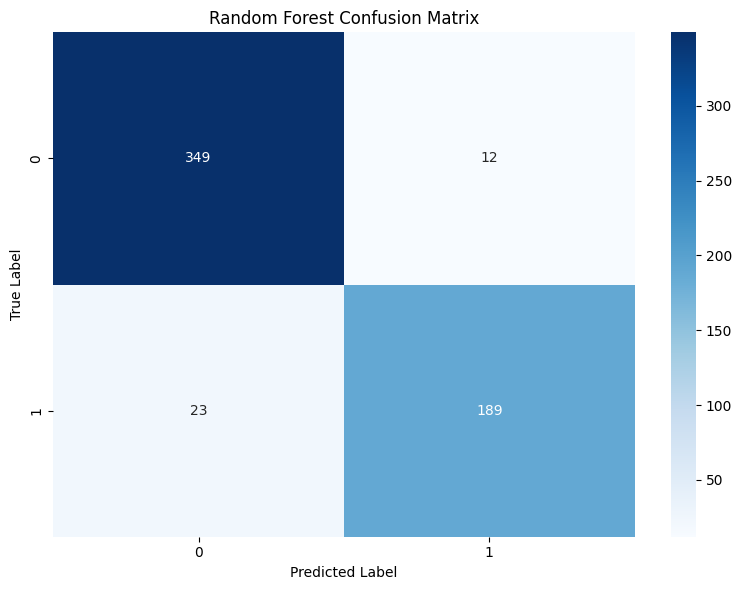

In [ ]:
rf_metrics, rf_y_test, rf_y_pred, = cf.evaluate_random_forest(
    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, cv_folds=10, random_state=42
)
vis.show_classfication_metrics(rf_metrics, model="Random Forest")
vis.plot_confusion_matrix(rf_y_test, rf_y_pred, title="Random Forest Confusion Matrix")

## Method #2